# Water Potability Analysis with Decision Tree


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)

## Step 2: Load the dataset

In [2]:
df = pd.read_csv("water_potability.csv")
df.head()

,ph,Hardness,Solids,Chloramines,Sulfate,Conductivity,Organic_carbon,Trihalomethanes,Turbidity,Potability
0,NaN,204.890455,20791.318981,7.300212,368.516441,564.308654,10.379783,86.990970,2.963135,0
1,3.716080,129.422921,18630.057858,6.635246,NaN,592.885359,15.180013,56.329076,4.500656,0
2,8.099124,224.236259,19909.541732,9.275884,NaN,418.606213,16.868637,66.420093,3.055934,0
3,8.316766,214.373394,22018.417441,8.059332,356.886136,363.266516,18.436524,100.341674,4.628771,0
4,9.092223,181.101509,17978.986339,6.546600,310.135738,398.410813,11.558279,31.997993,4.075075,0


## Step 3: Check the dataset shape and columns
This helps us understand how many rows and columns are present and what each feature is called.

In [3]:
print("Shape of dataset:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

Shape of dataset: (3276, 10)

Columns:
['ph', 'Hardness', 'Solids', 'Chloramines', 'Sulfate', 'Conductivity', 'Organic_carbon', 'Trihalomethanes', 'Turbidity', 'Potability']


## Step 4: Check missing values
Some features contain missing values, so we inspect them before training the model.

In [4]:
df.isnull().sum()

ph                 491
Hardness             0
Solids               0
Chloramines          0
Sulfate            781
Conductivity         0
Organic_carbon       0
Trihalomethanes    162
Turbidity            0
Potability           0
dtype: int64

## Step 5: Check potability class balance
This plot shows how many samples belong to each class in the target column `Potability`.

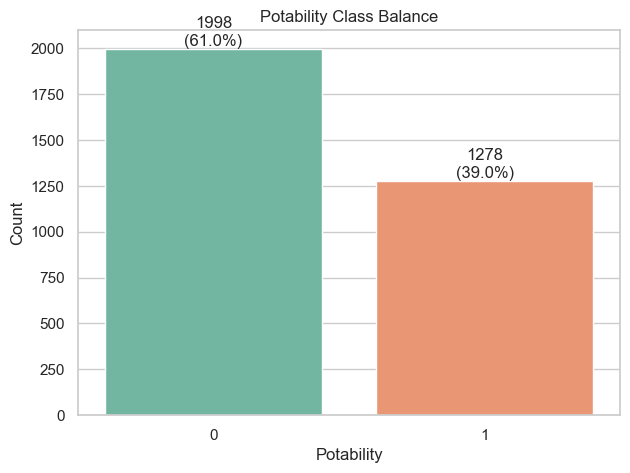

In [5]:
plt.figure(figsize=(7, 5))
ax = sns.countplot(data=df, x="Potability", hue="Potability", palette="Set2", legend=False)
ax.set_title("Potability Class Balance")
ax.set_xlabel("Potability")
ax.set_ylabel("Count")

total = len(df)
for patch in ax.patches:
    count = int(patch.get_height())
    pct = (count / total) * 100
    ax.annotate(f"{count}\n({pct:.1f}%)",
                (patch.get_x() + patch.get_width() / 2, patch.get_height()),
                ha="center", va="bottom")

plt.show()

## Step 6: Plot feature distributions
These histograms show how each feature is distributed and how it differs across the two potability classes.

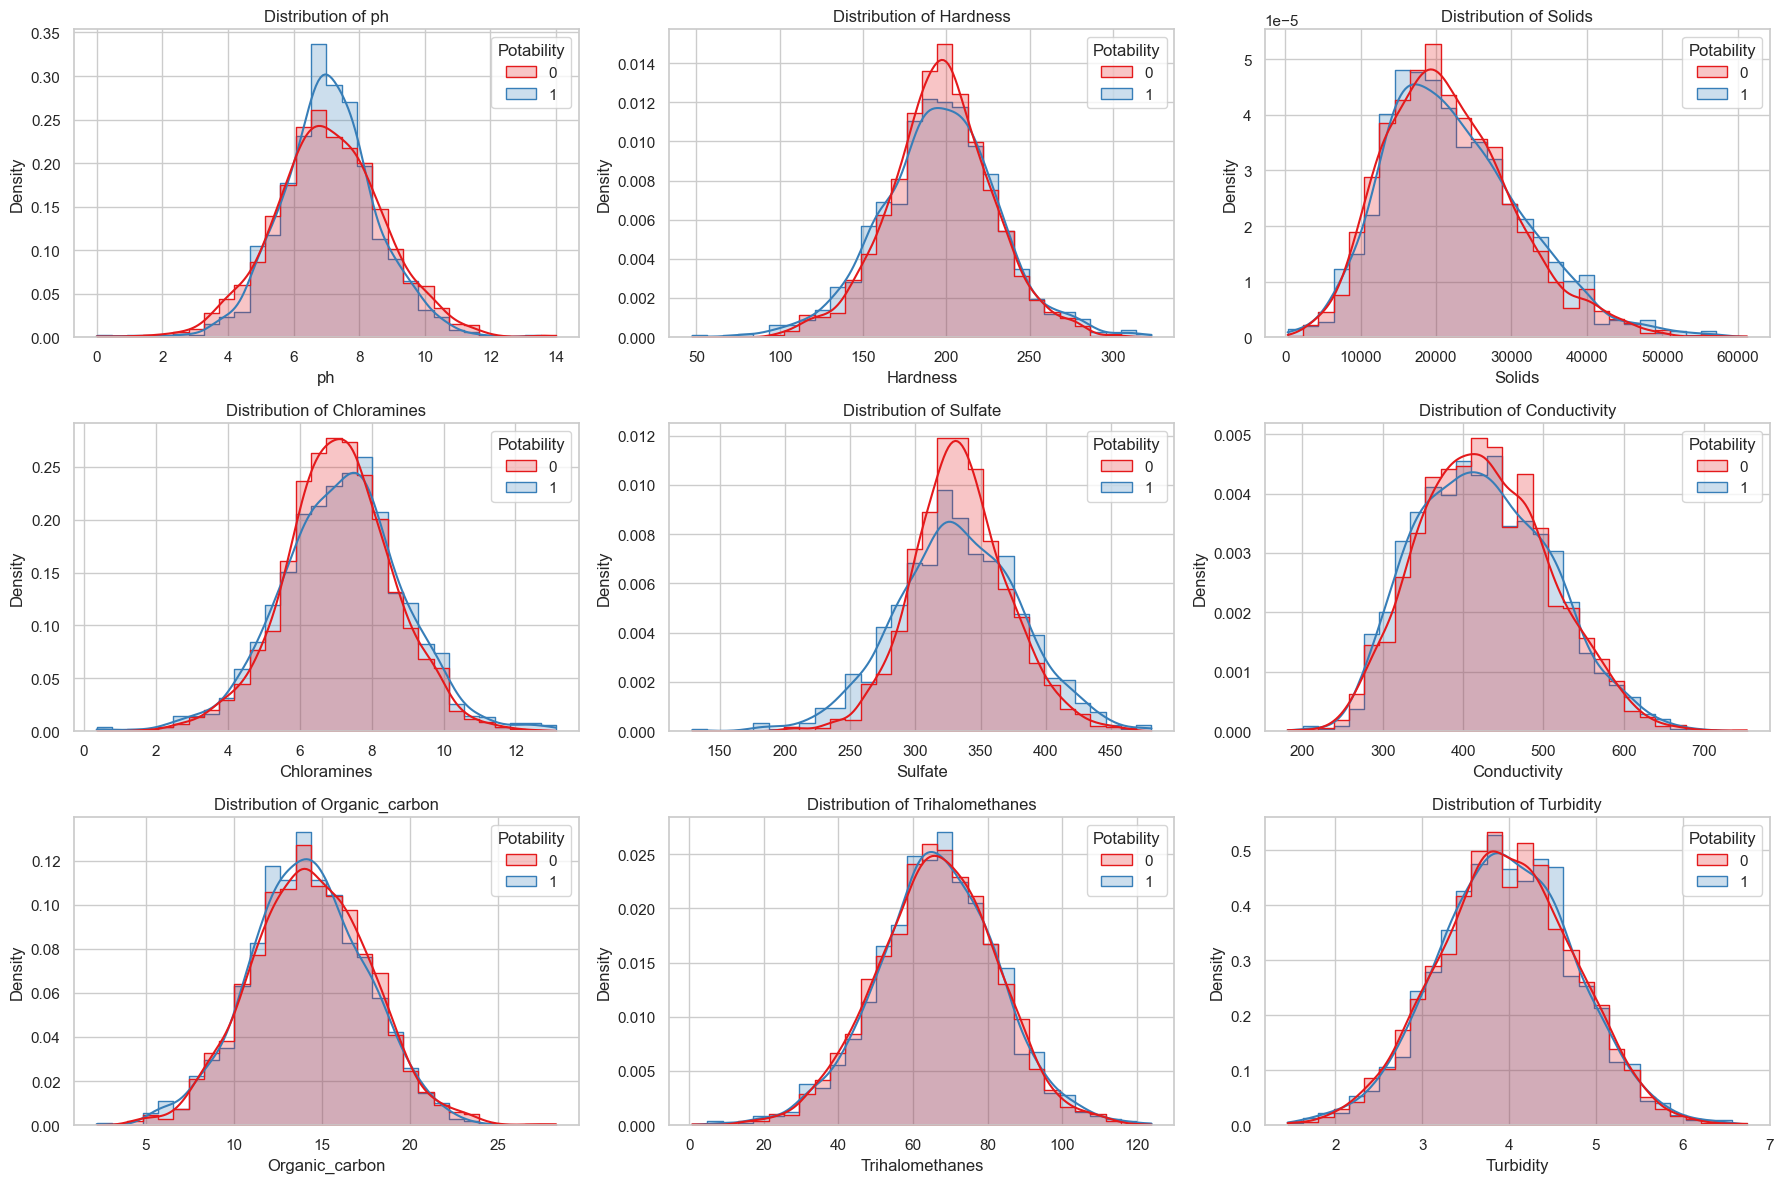

In [6]:
feature_columns = [col for col in df.columns if col != "Potability"]

n_cols = 3
n_rows = (len(feature_columns) + n_cols - 1) // n_cols
fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 4 * n_rows))
axes = axes.flatten()

for i, column in enumerate(feature_columns):
    sns.histplot(data=df, x=column, hue="Potability", kde=True, bins=30,
                 element="step", stat="density", common_norm=False,
                 palette="Set1", ax=axes[i])
    axes[i].set_title(f"Distribution of {column}")

for j in range(len(feature_columns), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

## Step 7: Plot the correlation heatmap
The heatmap helps us see the strength and direction of correlation between features.

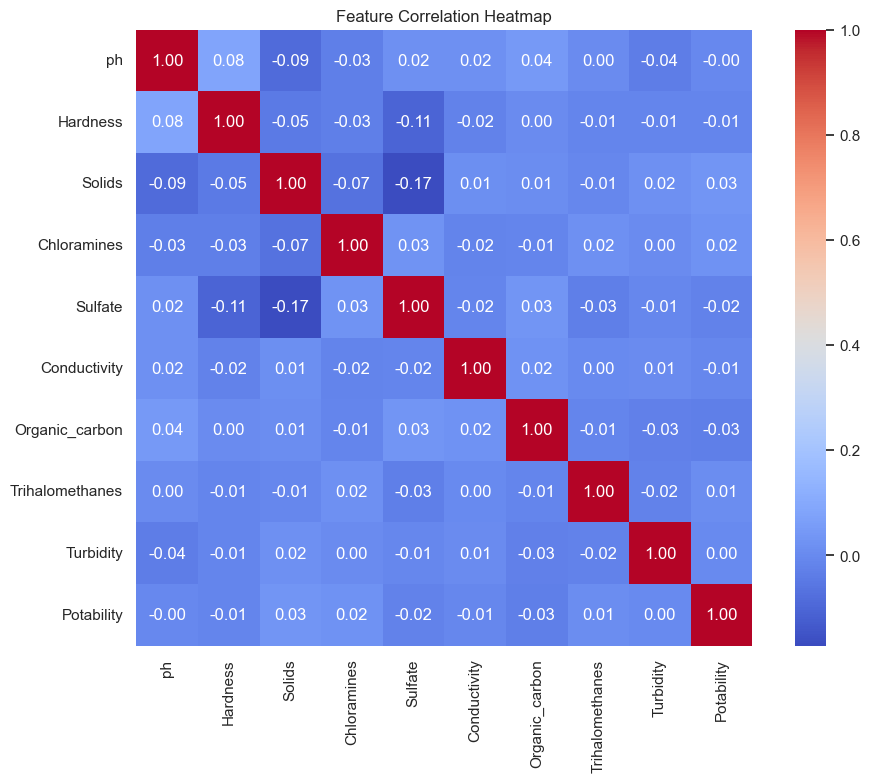

In [7]:
plt.figure(figsize=(11, 8))
corr = df.corr(numeric_only=True)
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f", square=True)
plt.title("Feature Correlation Heatmap")
plt.show()

## Step 8: Split the data into features and target
Here we separate the input columns from the target column.

In [8]:
X = df.drop("Potability", axis=1)
y = df["Potability"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Training set shape:", X_train.shape)
print("Test set shape:", X_test.shape)

Training set shape: (2620, 9)
Test set shape: (656, 9)


## Step 9: Build the preprocessing and Decision Tree pipeline
We fill missing values using the median of each feature, then train a Decision Tree classifier.

In [9]:
decision_tree_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("model", DecisionTreeClassifier(max_depth=6, random_state=42))
])

decision_tree_pipeline.fit(X_train, y_train)

Pipeline(steps=[('imputer', SimpleImputer(strategy='median')),
                ('model',
                 DecisionTreeClassifier(max_depth=6, random_state=42))])

## Step 10: Make predictions
After training, we use the model to predict the potability class for the test set.

In [10]:
y_pred = decision_tree_pipeline.predict(X_test)
y_pred[:10]

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0], dtype=int64)

## Step 11: Evaluate the Decision Tree model
We measure accuracy and print a classification report to understand precision, recall, and F1-score.

In [11]:
accuracy = accuracy_score(y_test, y_pred)
print(f"Decision Tree Accuracy: {accuracy:.4f}")
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred, zero_division=0))

Decision Tree Accuracy: 0.6418

Classification Report:

              precision    recall  f1-score   support

           0       0.65      0.89      0.75       400
           1       0.59      0.26      0.36       256

    accuracy                           0.64       656
   macro avg       0.62      0.57      0.56       656
weighted avg       0.63      0.64      0.60       656



## Step 12: Show the confusion matrix
The confusion matrix shows how many samples were classified correctly and incorrectly.

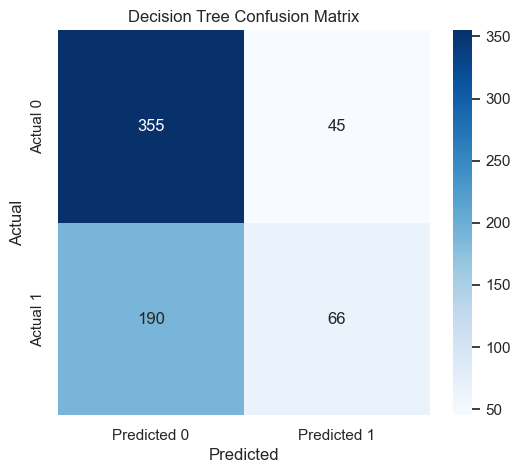

In [12]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Predicted 0", "Predicted 1"],
            yticklabels=["Actual 0", "Actual 1"])
plt.title("Decision Tree Confusion Matrix")
plt.ylabel("Actual")
plt.xlabel("Predicted")
plt.show()

## Step 13: Visualize the Decision Tree
This plot shows the learned tree structure so you can interpret the model splits.

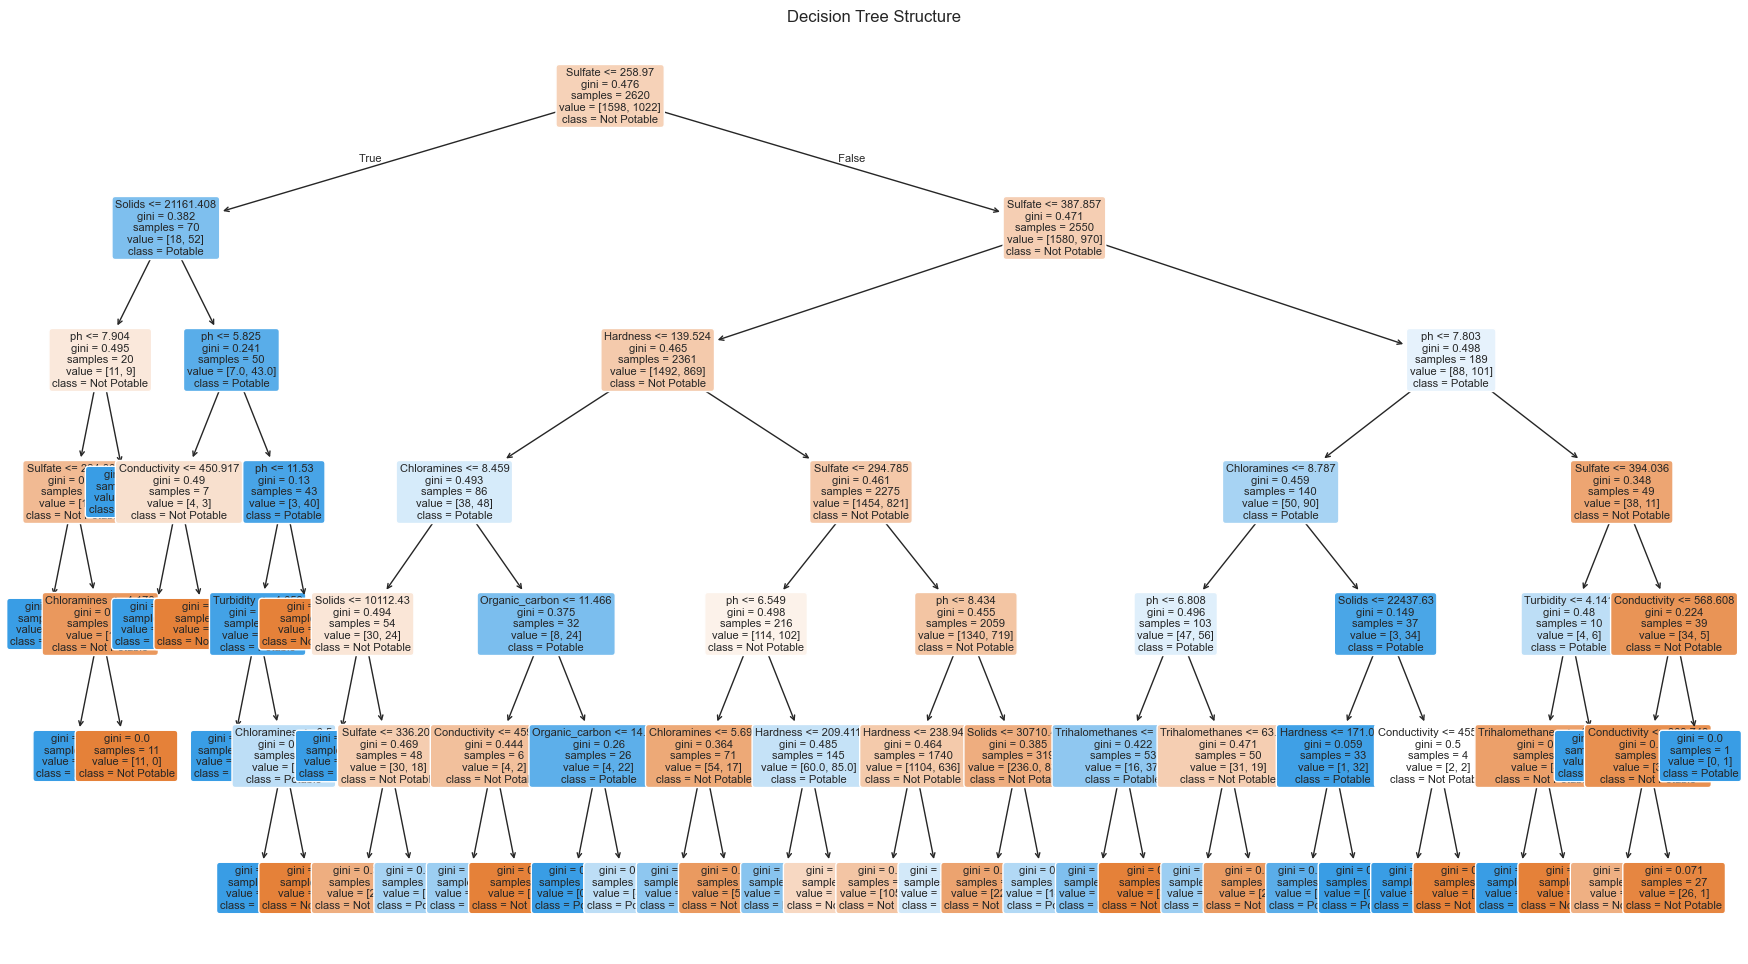

In [13]:
plt.figure(figsize=(22, 12))
plot_tree(
    decision_tree_pipeline.named_steps["model"],
    feature_names=X.columns,
    class_names=["Not Potable", "Potable"],
    filled=True,
    rounded=True,
    fontsize=8
)
plt.title("Decision Tree Structure")
plt.show()